# LightGBM Fine-tuning for M5 Forecasting — Hybrid Search

**Two-phase strategy:**

| Phase | Method | Purpose |
|---|---|---|
| **Phase 1** | 12-set grid search | Map the landscape — understand which param *directions* help |
| **Phase 2** | Focused Optuna search | Zoom into the best region and find the exact optimal combination |

**Why hybrid?** Grid search is fast and transparent. Optuna is smarter but needs a starting point. Together they give you both interpretability and precision.

**Outputs:**
1. `lgbm_grid_results_summary.csv` — Phase 1 comparison table
2. `lgbm_optuna_results.csv` — Phase 2 trial results
3. `best_lgbm_params.json` — Overall best params (grid or Optuna, whichever wins)
4. `feature_importance.png` — Feature importance from best model

> M5 is officially scored on WRMSSE. RMSE is used here as a valid proxy — lower RMSE reliably tracks lower WRMSSE for hyperparameter comparison purposes.

## 0. Environment setup

In [ ]:
# Uncomment if running on Colab:
!pip install lightgbm pyarrow scikit-learn optuna -q

import os, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import lightgbm as lgb
import optuna
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-trial Optuna logs

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', 100)

# from google.colab import drive
# # drive.mount('/content/drive')  # Colab only  # Colab only


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Load parquet (memory-efficient)

Read only `id` + `dept_id` first, do stratified sampling, then load only the sampled rows.

In [ ]:
#DATA_PATH = Path('long_df_with_features.parquet')
# Update DATA_PATH to match your local environment.
DATA_PATH = Path("../results/long_df_with_features.parquet")  # output of notebook 03

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Cannot find {DATA_PATH}. Update DATA_PATH.')

pf       = pq.ParquetFile(DATA_PATH)
id_meta  = pf.read(columns=['id', 'dept_id']).to_pandas()
uid_dept = id_meta.drop_duplicates('id')[['id', 'dept_id']]

print(f'Total unique IDs: {uid_dept["id"].nunique()}')
print('dept_id distribution:')
print(uid_dept['dept_id'].value_counts())
del id_meta


Total unique IDs: 30490
dept_id distribution:
dept_id
FOODS_3        8230
HOUSEHOLD_1    5320
HOUSEHOLD_2    5150
HOBBIES_1      4160
FOODS_2        3980
FOODS_1        2160
HOBBIES_2      1490
Name: count, dtype: int64


## 2. Stratified ID sampling

`dept_id` is skewed (FOODS_3 = 8,230 IDs, HOBBIES_2 = 1,490). Proportional stratified sampling keeps the tuning signal representative of the full M5 dataset.

In [ ]:
N_SAMPLE_IDS = 1000

dept_counts = uid_dept['dept_id'].value_counts()
total_ids   = dept_counts.sum()
sampled_ids = []

for dept, count in dept_counts.items():
    n = max(1, round(N_SAMPLE_IDS * count / total_ids))
    dept_ids = uid_dept.loc[uid_dept['dept_id'] == dept, 'id'].values
    chosen   = np.random.choice(dept_ids, size=min(n, len(dept_ids)), replace=False)
    sampled_ids.extend(chosen.tolist())

sampled_ids = sampled_ids[:N_SAMPLE_IDS]
print(f'Sampled {len(sampled_ids)} IDs (stratified by dept_id)')

df = pd.read_parquet(DATA_PATH, filters=[('id', 'in', sampled_ids)])
print(f'Loaded shape: {df.shape}')
display(df.head())

Sampled 1000 IDs (stratified by dept_id)
Loaded shape: (528000, 21)


,id,item_id,dept_id,cat_id,store_id,state_id,date,demand,is_active,sell_price,price_change,is_promo,dow,month,lag_7,lag_28,rmean_7,rmean_28,lag_56,snap_flag,is_event
0,FOODS_1_005_WI_3_evaluation,FOODS_1_005,FOODS_1,FOODS,WI_3,WI,2014-12-12,0,1,3.54,0.0,0,4,12,NaN,NaN,NaN,NaN,NaN,1,0
1,FOODS_1_005_WI_3_evaluation,FOODS_1_005,FOODS_1,FOODS,WI_3,WI,2014-12-13,0,1,3.54,0.0,0,5,12,NaN,NaN,NaN,NaN,NaN,0,0
2,FOODS_1_005_WI_3_evaluation,FOODS_1_005,FOODS_1,FOODS,WI_3,WI,2014-12-14,0,1,3.54,0.0,0,6,12,NaN,NaN,NaN,NaN,NaN,1,0
3,FOODS_1_005_WI_3_evaluation,FOODS_1_005,FOODS_1,FOODS,WI_3,WI,2014-12-15,0,1,3.54,0.0,0,0,12,NaN,NaN,NaN,NaN,NaN,1,0
4,FOODS_1_005_WI_3_evaluation,FOODS_1_005,FOODS_1,FOODS,WI_3,WI,2014-12-16,0,1,3.54,0.0,0,1,12,NaN,NaN,NaN,NaN,NaN,0,0


## 3. Column configuration

In [ ]:
TARGET   = next((c for c in ['sales','demand','target','y']        if c in df.columns), None)
ID_COL   = next((c for c in ['id','item_store_id','series_id']     if c in df.columns), None)
TIME_COL = next((c for c in ['d','date','day','day_num','wm_yr_wk'] if c in df.columns), None)

for name, val in [('TARGET', TARGET), ('ID_COL', ID_COL), ('TIME_COL', TIME_COL)]:
    if val is None:
        raise ValueError(f'Cannot auto-detect {name}. Set manually. Cols: {df.columns.tolist()}')
    print(f'{name}: {val}')

TARGET: demand
ID_COL: id
TIME_COL: date


## 4. Time split — latest 500 days, last 28 days = validation

Validation window matches the M5 test horizon exactly (28 days).

In [ ]:
N_TUNING_DAYS = 500
VALID_DAYS    = 28

if TIME_COL == 'd':
    df['day_num'] = df[TIME_COL].astype(str).str.replace('d_', '', regex=False).astype(int)
elif np.issubdtype(df[TIME_COL].dtype, np.datetime64):
    df['day_num'] = df[TIME_COL].rank(method='dense').astype(int)
else:
    df[TIME_COL]  = pd.to_datetime(df[TIME_COL], errors='coerce')
    df['day_num'] = df[TIME_COL].rank(method='dense').astype(int)

max_day            = int(df['day_num'].max())
min_day_for_tuning = max_day - N_TUNING_DAYS + 1
valid_start_day    = max_day - VALID_DAYS + 1

df_tune  = df[df['day_num'] >= min_day_for_tuning].copy()
train_df = df_tune[df_tune['day_num'] <  valid_start_day].copy()
valid_df = df_tune[df_tune['day_num'] >= valid_start_day].copy()

print(f'Tuning window: day {int(df_tune["day_num"].min())} to {max_day}  ({df_tune["day_num"].nunique()} days)')
print(f'Train:      {train_df.shape[0]:,} rows')
print(f'Validation: {valid_df.shape[0]:,} rows  (days {int(valid_df["day_num"].min())}–{max_day})')

Tuning window: day 29 to 528  (500 days)
Train:      472,000 rows
Validation: 28,000 rows  (days 501–528)


## 5. Feature setup

- Drop NaN rows from lag features (warmup period — no valid signal).
- Drop composite `id` string but **keep** `item_id`, `dept_id`, `cat_id`, `store_id`, `state_id` as categorical features.

In [ ]:
LAG_COLS = [c for c in ['lag_7','lag_28','lag_56','rmean_7','rmean_28'] if c in train_df.columns]

before    = len(train_df)
train_df  = train_df.dropna(subset=LAG_COLS).copy()
before_v  = len(valid_df)
valid_df  = valid_df.dropna(subset=LAG_COLS).copy()
print(f'Dropped {before - len(train_df):,} NaN-lag rows from train  ({(before-len(train_df))/before:.1%})')
print(f'Dropped {before_v - len(valid_df):,} NaN-lag rows from validation')

DROP_COLS = {TARGET, 'day_num', TIME_COL, ID_COL}
FEATURES  = [c for c in df_tune.columns if c not in DROP_COLS]

categorical_features = []
for col in FEATURES:
    if train_df[col].dtype == 'object' or str(train_df[col].dtype) == 'category':
        train_df[col] = train_df[col].astype('category')
        valid_df[col] = valid_df[col].astype('category')
        categorical_features.append(col)

X_train = train_df[FEATURES];  y_train = train_df[TARGET]
X_valid = valid_df[FEATURES];  y_valid = valid_df[TARGET]

print(f'\nFeatures ({len(FEATURES)}): {FEATURES}')
print(f'Categorical: {categorical_features}')
print(f'X_train: {X_train.shape} | X_valid: {X_valid.shape}')

Dropped 28,000 NaN-lag rows from train  (5.9%)
Dropped 0 NaN-lag rows from validation

Features (18): ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'is_active', 'sell_price', 'price_change', 'is_promo', 'dow', 'month', 'lag_7', 'lag_28', 'rmean_7', 'rmean_28', 'lag_56', 'snap_flag', 'is_event']
Categorical: ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
X_train: (444000, 18) | X_valid: (28000, 18)


## 6. Shared training constants

In [ ]:
NUM_BOOST_ROUND       = 2000
EARLY_STOPPING_ROUNDS = 100
VERBOSE_EVAL          = 200   # print every N rounds during grid search

BASELINE_PARAMS = {
    'objective'              : 'tweedie',
    'tweedie_variance_power' : 1.5,
    'metric'                 : 'rmse',
    'boosting_type'          : 'gbdt',
    'learning_rate'          : 0.05,
    'num_leaves'             : 127,
    'min_data_in_leaf'       : 100,
    'feature_fraction'       : 0.8,
    'bagging_fraction'       : 0.8,
    'bagging_freq'           : 1,
    'lambda_l1'              : 0.0,
    'lambda_l2'              : 0.1,
    'seed'                   : RANDOM_STATE,
    'verbosity'              : -1,
}

def calc_rmse(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    try:
        return float(mean_squared_error(y_true, y_pred, squared=False))
    except TypeError:
        return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def make_datasets():
    """Always create fresh LGB datasets — reusing after lgb.train() causes state leakage."""
    lgb_tr = lgb.Dataset(X_train, label=y_train,
                         categorical_feature=categorical_features or 'auto',
                         free_raw_data=False)
    lgb_va = lgb.Dataset(X_valid, label=y_valid, reference=lgb_tr,
                         categorical_feature=categorical_features or 'auto',
                         free_raw_data=False)
    return lgb_tr, lgb_va

---
# Phase 1 — Grid Search (12 sets)

Goal: quickly map which parameter *directions* help before zooming in.

| Group | Sets | What it tests |
|---|---|---|
| Baseline | `baseline` | Your original FE-stage params |
| Learning rate | `set_01` | Slower, more stable training |
| Tree size | `set_02`, `set_03` | More vs fewer leaves |
| Regularization | `set_04`, `set_09`, `set_10` | L1/L2 + leaf size combos |
| Flexibility | `set_05` | Smaller min_leaf, more sampling |
| Tweedie power | `set_06`, `set_07`, `set_11` | Demand sparsity assumption |
| Combined | `set_08` | High capacity + slow learning |

In [ ]:
PARAM_GRID = [
    {
        'experiment_name'  : 'baseline',
        'training_summary' : 'Original FE-stage params.',
        'params'           : {**BASELINE_PARAMS},
    },
    {
        'experiment_name'  : 'set_01_lower_lr',
        'training_summary' : 'Slower learning rate — more iterations, more stable.',
        'params'           : {**BASELINE_PARAMS, 'learning_rate': 0.03},
    },
    {
        'experiment_name'  : 'set_02_larger_tree',
        'training_summary' : 'More leaves (255) — higher capacity, finer patterns.',
        'params'           : {**BASELINE_PARAMS, 'num_leaves': 255},
    },
    {
        'experiment_name'  : 'set_03_smaller_tree',
        'training_summary' : 'Fewer leaves (63) — conservative, less overfit risk.',
        'params'           : {**BASELINE_PARAMS, 'num_leaves': 63},
    },
    {
        'experiment_name'  : 'set_04_stronger_reg',
        'training_summary' : 'Larger min_leaf + stronger L1+L2 — simpler splits.',
        'params'           : {**BASELINE_PARAMS, 'min_data_in_leaf': 200, 'lambda_l1': 0.1, 'lambda_l2': 1.0},
    },
    {
        'experiment_name'  : 'set_05_more_flexible',
        'training_summary' : 'Small min_leaf + more feature/bagging — flexible model.',
        'params'           : {**BASELINE_PARAMS, 'min_data_in_leaf': 50, 'feature_fraction': 0.9, 'bagging_fraction': 0.9},
    },
    {
        'experiment_name'  : 'set_06_tweedie_low',
        'training_summary' : 'Tweedie power=1.2 — closer to Gaussian, better for stable high-demand products.',
        'params'           : {**BASELINE_PARAMS, 'tweedie_variance_power': 1.2},
    },
    {
        'experiment_name'  : 'set_07_tweedie_high',
        'training_summary' : 'Tweedie power=1.7 — closer to Poisson, better for sparse/intermittent demand.',
        'params'           : {**BASELINE_PARAMS, 'tweedie_variance_power': 1.7},
    },
    {
        'experiment_name'  : 'set_08_complex_slow',
        'training_summary' : 'Large tree (255) + slow LR (0.03) — high capacity + careful training.',
        'params'           : {**BASELINE_PARAMS, 'num_leaves': 255, 'learning_rate': 0.03},
    },
    {
        'experiment_name'  : 'set_09_high_l1',
        'training_summary' : 'High L1 (1.0) — feature sparsity, good when some features are noisy.',
        'params'           : {**BASELINE_PARAMS, 'lambda_l1': 1.0, 'lambda_l2': 0.0},
    },
    {
        'experiment_name'  : 'set_10_conservative_combo',
        'training_summary' : 'Small tree + slow LR + large min_leaf — maximum conservatism.',
        'params'           : {**BASELINE_PARAMS, 'num_leaves': 63, 'learning_rate': 0.03, 'min_data_in_leaf': 200},
    },
    {
        'experiment_name'  : 'set_11_tweedie_mid',
        'training_summary' : 'Tweedie power=1.35 — midpoint, tests the gap between 1.2 and 1.5.',
        'params'           : {**BASELINE_PARAMS, 'tweedie_variance_power': 1.35},
    },
]

def summarize_changes(params, baseline=BASELINE_PARAMS):
    keys = ['learning_rate','num_leaves','min_data_in_leaf',
            'feature_fraction','bagging_fraction',
            'lambda_l1','lambda_l2','tweedie_variance_power']
    changes = [f"{k}: {baseline.get(k)} -> {params.get(k)}"
               for k in keys if params.get(k) != baseline.get(k)]
    return 'Baseline' if not changes else '; '.join(changes)

print(f'{len(PARAM_GRID)} parameter sets defined.')

12 parameter sets defined.


## 7. Run Phase 1 — grid search loop

In [ ]:
grid_results = []
grid_models  = {}

for exp in PARAM_GRID:
    name    = exp['experiment_name']
    summary = exp['training_summary']
    params  = exp['params']

    print(f'\n{"+" * 70}')
    print(f'  {name}')
    print(f'  {summary}')
    print(f'  Changes: {summarize_changes(params)}')
    print(f'{"+" * 70}')

    lgb_tr, lgb_va = make_datasets()

    model = lgb.train(
        params=params,
        train_set=lgb_tr,
        num_boost_round=NUM_BOOST_ROUND,
        valid_sets=[lgb_tr, lgb_va],
        valid_names=['train', 'valid'],
        callbacks=[
            lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
            lgb.log_evaluation(VERBOSE_EVAL),
        ],
    )

    rmse = calc_rmse(y_valid, model.predict(X_valid, num_iteration=model.best_iteration))
    grid_models[name] = model

    row = {
        'experiment_name' : name,
        'training_summary': summary,
        'tuning_parameter': summarize_changes(params),
        'valid_rmse'      : round(rmse, 6),
        'best_iteration'  : model.best_iteration,
    }
    row.update(params)
    grid_results.append(row)
    print(f'  => RMSE: {rmse:.6f}  |  best_iter: {model.best_iteration}')

print('\nPhase 1 complete.')


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  baseline
  Original FE-stage params.
  Changes: Baseline
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
[200]	train's rmse: 1.78629	valid's rmse: 2.03663
  => RMSE: 2.011154  |  best_iter: 122

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  set_01_lower_lr
  Slower learning rate — more iterations, more stable.
  Changes: learning_rate: 0.05 -> 0.03
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
[200]	train's rmse: 1.82546	valid's rmse: 2.02299
  => RMSE: 2.020545  |  best_iter: 178

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  set_02_larger_tree
  More leaves (255) — higher capacity, finer patterns.
  Changes: num_leaves: 127 -> 255
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
[200]	train's rmse: 1.73446	valid's rmse: 2.05744
  => RMSE: 2.035345  |  best_iter: 105

++++++++++++++++++++++

## 8. Phase 1 results

In [ ]:
grid_df = pd.DataFrame(grid_results).sort_values('valid_rmse').reset_index(drop=True)
summary_cols = ['experiment_name','training_summary','tuning_parameter','valid_rmse','best_iteration']

print('Phase 1 — Grid Search Results (ranked by RMSE):')
display(grid_df[summary_cols])

grid_df[summary_cols].to_csv('lgbm_grid_results_summary.csv', index=False)
grid_df.to_csv('lgbm_grid_results_full.csv', index=False)
print('Saved lgbm_grid_results_summary.csv')

# Identify winner and its param values — used to anchor Phase 2 search space
grid_best_name   = grid_df.iloc[0]['experiment_name']
grid_best_rmse   = grid_df.iloc[0]['valid_rmse']
grid_best_params = next(e['params'] for e in PARAM_GRID if e['experiment_name'] == grid_best_name)

print(f'\nPhase 1 winner: {grid_best_name}  (RMSE={grid_best_rmse:.6f})')
print(f'Winning params: {summarize_changes(grid_best_params)}')

Phase 1 — Grid Search Results (ranked by RMSE):


,experiment_name,training_summary,tuning_parameter,valid_rmse,best_iteration
0,set_06_tweedie_low,"Tweedie power=1.2 — closer to Gaussian, better for stable high-demand products.",tweedie_variance_power: 1.5 -> 1.2,2.006468,77
1,baseline,Original FE-stage params.,Baseline,2.011154,122
2,set_03_smaller_tree,"Fewer leaves (63) — conservative, less overfit risk.",num_leaves: 127 -> 63,2.013760,171
3,set_04_stronger_reg,Larger min_leaf + stronger L1+L2 — simpler splits.,min_data_in_leaf: 100 -> 200; lambda_l1: 0.0 -> 0.1; lambda_l2: 0.1 -> 1.0,2.016111,125
4,set_10_conservative_combo,Small tree + slow LR + large min_leaf — maximum conservatism.,learning_rate: 0.05 -> 0.03; num_leaves: 127 -> 63; min_data_in_leaf: 100 -> 200,2.018322,299
5,set_11_tweedie_mid,"Tweedie power=1.35 — midpoint, tests the gap between 1.2 and 1.5.",tweedie_variance_power: 1.5 -> 1.35,2.019889,112
6,set_09_high_l1,"High L1 (1.0) — feature sparsity, good when some features are noisy.",lambda_l1: 0.0 -> 1.0; lambda_l2: 0.1 -> 0.0,2.020322,110
7,set_01_lower_lr,"Slower learning rate — more iterations, more stable.",learning_rate: 0.05 -> 0.03,2.020545,178
8,set_08_complex_slow,Large tree (255) + slow LR (0.03) — high capacity + careful training.,learning_rate: 0.05 -> 0.03; num_leaves: 127 -> 255,2.030416,173
9,set_05_more_flexible,Small min_leaf + more feature/bagging — flexible model.,min_data_in_leaf: 100 -> 50; feature_fraction: 0.8 -> 0.9; bagging_fraction: 0.8 -> 0.9,2.030734,122


Saved lgbm_grid_results_summary.csv

Phase 1 winner: set_06_tweedie_low  (RMSE=2.006468)
Winning params: tweedie_variance_power: 1.5 -> 1.2


---
# Phase 2 — Focused Optuna Search

Phase 1 told us *which direction* helps. Now Optuna searches a **narrow window around the Phase 1 winner** using Bayesian optimization (TPE sampler).

**How the focused window works:**

Each parameter's search range is computed from the Phase 1 best values:
- If `num_leaves` was 255 → search [160, 380]
- If `learning_rate` was 0.03 → search [0.015, 0.07]
- etc.

This means Optuna isn't searching randomly across the full space — it starts from a known good region and refines from there.

In [ ]:
N_OPTUNA_TRIALS = 40   # increase to 60-80 if you have more time

def build_focused_space(best_p):
    """
    Compute focused search ranges centred on the Phase 1 best params.
    Each range is roughly ±40-50% around the best value, with hard boundaries.
    """
    lr      = best_p['learning_rate']
    leaves  = best_p['num_leaves']
    min_lf  = best_p['min_data_in_leaf']
    tvp     = best_p['tweedie_variance_power']
    l1      = best_p['lambda_l1']
    l2      = best_p['lambda_l2']
    ff      = best_p['feature_fraction']
    bf      = best_p['bagging_fraction']

    space = {
        # (low, high) tuples
        'learning_rate'          : (max(0.005, lr * 0.4),       min(0.15,  lr * 2.5)),
        'num_leaves'             : (max(31,    int(leaves*0.6)), min(512,   int(leaves*1.6))),
        'min_data_in_leaf'       : (max(20,    int(min_lf*0.4)), min(500,   int(min_lf*2.5))),
        'tweedie_variance_power' : (max(1.01,  tvp - 0.35),     min(1.99,  tvp + 0.35)),
        'lambda_l1'              : (max(0.0,   l1 - 0.5),       min(3.0,   l1 + 1.5)),
        'lambda_l2'              : (max(0.0,   l2 - 0.5),       min(3.0,   l2 + 1.5)),
        'feature_fraction'       : (max(0.5,   ff - 0.2),       min(1.0,   ff + 0.15)),
        'bagging_fraction'       : (max(0.5,   bf - 0.2),       min(1.0,   bf + 0.15)),
    }
    return space

OPTUNA_SPACE = build_focused_space(grid_best_params)

print('Focused Optuna search space (built from Phase 1 winner):')
print(f'  Phase 1 winner: {grid_best_name}')
print()
for param, (lo, hi) in OPTUNA_SPACE.items():
    best_val = grid_best_params.get(param, '—')
    print(f'  {param:<28} best={best_val}   search=[{lo:.4g}, {hi:.4g}]')

Focused Optuna search space (built from Phase 1 winner):
  Phase 1 winner: set_06_tweedie_low

  learning_rate                best=0.05   search=[0.02, 0.125]
  num_leaves                   best=127   search=[76, 203]
  min_data_in_leaf             best=100   search=[40, 250]
  tweedie_variance_power       best=1.2   search=[1.01, 1.55]
  lambda_l1                    best=0.0   search=[0, 1.5]
  lambda_l2                    best=0.1   search=[0, 1.6]
  feature_fraction             best=0.8   search=[0.6, 0.95]
  bagging_fraction             best=0.8   search=[0.6, 0.95]


## 10. Optuna objective function

In [ ]:
def optuna_objective(trial):
    sp = OPTUNA_SPACE

    params = {
        'objective'              : 'tweedie',
        'metric'                 : 'rmse',
        'boosting_type'          : 'gbdt',
        'bagging_freq'           : 1,
        'verbosity'              : -1,
        'seed'                   : RANDOM_STATE,
        # --- tuned by Optuna ---
        'learning_rate'          : trial.suggest_float('learning_rate',
                                        *sp['learning_rate'], log=True),
        'num_leaves'             : trial.suggest_int('num_leaves',
                                        *sp['num_leaves']),
        'min_data_in_leaf'       : trial.suggest_int('min_data_in_leaf',
                                        *sp['min_data_in_leaf']),
        'tweedie_variance_power' : trial.suggest_float('tweedie_variance_power',
                                        *sp['tweedie_variance_power']),
        'lambda_l1'              : trial.suggest_float('lambda_l1',
                                        *sp['lambda_l1']),
        'lambda_l2'              : trial.suggest_float('lambda_l2',
                                        *sp['lambda_l2']),
        'feature_fraction'       : trial.suggest_float('feature_fraction',
                                        *sp['feature_fraction']),
        'bagging_fraction'       : trial.suggest_float('bagging_fraction',
                                        *sp['bagging_fraction']),
    }

    lgb_tr, lgb_va = make_datasets()

    model = lgb.train(
        params=params,
        train_set=lgb_tr,
        num_boost_round=NUM_BOOST_ROUND,
        valid_sets=[lgb_va],
        valid_names=['valid'],
        callbacks=[
            lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
            lgb.log_evaluation(-1),
        ],
    )

    rmse = calc_rmse(y_valid, model.predict(X_valid, num_iteration=model.best_iteration))

    # Save best_iteration so we can retrieve it later without retraining
    trial.set_user_attr('best_iteration', model.best_iteration)

    return rmse

## 11. Run Phase 2 — Optuna study

`TPESampler` (Tree-structured Parzen Estimator) is the default Bayesian sampler. It builds a probability model of which param combinations are promising after each trial and samples the next trial from the high-probability region.

In [ ]:
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name='lgbm_m5_focused',
)

print(f'Starting Optuna search — {N_OPTUNA_TRIALS} trials focused around: {grid_best_name}')
print(f'Phase 1 baseline to beat: RMSE = {grid_best_rmse:.6f}\n')

study.optimize(
    optuna_objective,
    n_trials=N_OPTUNA_TRIALS,
    show_progress_bar=True,
)

optuna_best_rmse      = study.best_value
optuna_best_params_raw = study.best_params
optuna_best_iter      = study.best_trial.user_attrs['best_iteration']

print(f'\nPhase 2 best RMSE:      {optuna_best_rmse:.6f}')
print(f'Phase 2 best iteration: {optuna_best_iter}')
print(f'Phase 2 best params:')
for k, v in optuna_best_params_raw.items():
    print(f'  {k}: {v}')

Starting Optuna search — 40 trials focused around: set_06_tweedie_low
Phase 1 baseline to beat: RMSE = 2.006468



  0%|          | 0/40 [00:00<?, ?it/s]


Phase 2 best RMSE:      2.002561
Phase 2 best iteration: 152
Phase 2 best params:
  learning_rate: 0.041858462747989315
  num_leaves: 91
  min_data_in_leaf: 85
  tweedie_variance_power: 1.2765900380701871
  lambda_l1: 0.8683198414627746
  lambda_l2: 0.35976328628132526
  feature_fraction: 0.6987745525049156
  bagging_fraction: 0.8688864780847736


## 12. Phase 2 results + comparison with Phase 1

In [ ]:
# Build full Optuna results table
optuna_rows = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        row = {'trial_number': t.number, 'valid_rmse': round(t.value, 6)}
        row.update(t.params)
        row['best_iteration'] = t.user_attrs.get('best_iteration', None)
        optuna_rows.append(row)

optuna_df = pd.DataFrame(optuna_rows).sort_values('valid_rmse').reset_index(drop=True)
optuna_df.to_csv('lgbm_optuna_results.csv', index=False)
print('Saved lgbm_optuna_results.csv')
print()
print('Top 10 Optuna trials:')
display(optuna_df.head(10))

# ── Head-to-head comparison ───────────────────────────────────────────────────
print()
print('=' * 55)
print('         HEAD-TO-HEAD COMPARISON')
print('=' * 55)
print(f'  Phase 1 best  ({grid_best_name}):')
print(f'    RMSE = {grid_best_rmse:.6f}')
print()
print(f'  Phase 2 best  (Optuna trial #{study.best_trial.number}):')
print(f'    RMSE = {optuna_best_rmse:.6f}')
improvement = (grid_best_rmse - optuna_best_rmse) / grid_best_rmse * 100
print()
if optuna_best_rmse < grid_best_rmse:
    print(f'  => Optuna wins by {improvement:.2f}% improvement')
else:
    print(f'  => Grid search holds — Optuna did not improve (diff={improvement:.2f}%)')
    print(f'     Use the Phase 1 best params for final training.')
print('=' * 55)

Saved lgbm_optuna_results.csv

Top 10 Optuna trials:


,trial_number,valid_rmse,learning_rate,num_leaves,min_data_in_leaf,tweedie_variance_power,lambda_l1,lambda_l2,feature_fraction,bagging_fraction,best_iteration
0,37,2.002561,0.041858,91,85,1.276590,0.868320,0.359763,0.698775,0.868886,152
1,28,2.008709,0.048840,131,78,1.336678,1.326412,0.710722,0.602454,0.903835,120
2,34,2.009045,0.042001,107,84,1.270276,0.932211,0.510501,0.653556,0.917477,128
3,39,2.010110,0.058237,107,113,1.523453,1.092216,0.523436,0.725969,0.949907,139
4,25,2.010270,0.043776,154,106,1.247964,1.045460,0.459647,0.635581,0.909865,112
5,35,2.010968,0.041598,99,82,1.274301,1.010593,0.008734,0.650844,0.915678,128
6,29,2.012572,0.037636,120,76,1.374102,1.344146,0.667061,0.619207,0.906889,150
7,11,2.013045,0.036939,202,129,1.202289,0.895821,0.632108,0.616313,0.844499,122
8,20,2.013819,0.062917,185,142,1.226522,1.486916,0.884455,0.678640,0.854326,76
9,30,2.015145,0.045640,119,70,1.346125,1.324157,0.344277,0.625101,0.908571,125



         HEAD-TO-HEAD COMPARISON
  Phase 1 best  (set_06_tweedie_low):
    RMSE = 2.006468

  Phase 2 best  (Optuna trial #37):
    RMSE = 2.002561

  => Optuna wins by 0.19% improvement


## 13. Optuna visualisation

The optimisation history shows RMSE over trials. You should see it generally decrease and flatten out — that's the Bayesian sampler converging.

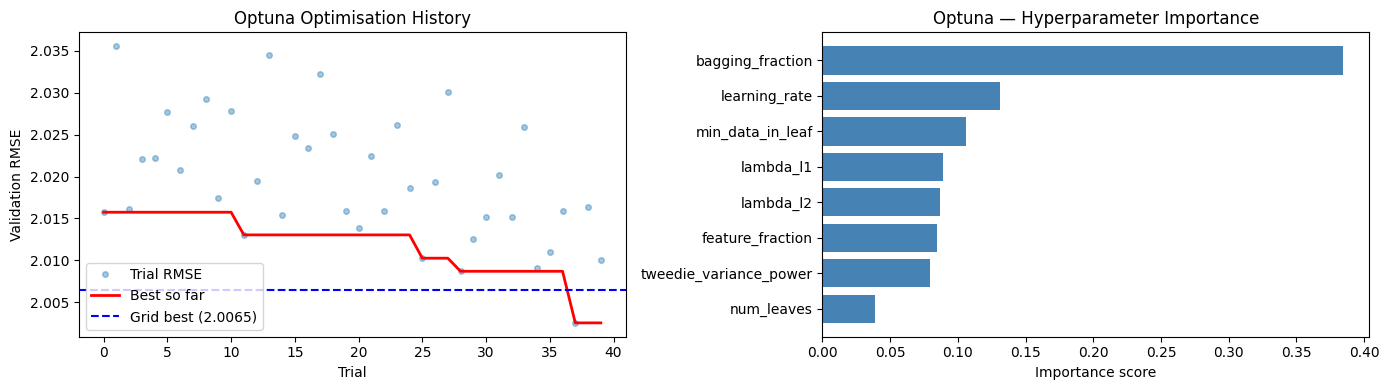

Saved optuna_summary.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: optimisation history
trial_nums = [t.number for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
trial_vals = [t.value  for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
running_best = pd.Series(trial_vals).cummin()

axes[0].plot(trial_nums, trial_vals,    'o', alpha=0.4, markersize=4, label='Trial RMSE')
axes[0].plot(trial_nums, running_best,  '-', linewidth=2, color='red',  label='Best so far')
axes[0].axhline(grid_best_rmse, linestyle='--', color='blue', label=f'Grid best ({grid_best_rmse:.4f})')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Validation RMSE')
axes[0].set_title('Optuna Optimisation History')
axes[0].legend()

# Right: param importance
try:
    importances = optuna.importance.get_param_importances(study)
    params_sorted = list(importances.keys())
    vals_sorted   = [importances[p] for p in params_sorted]
    axes[1].barh(params_sorted[::-1], vals_sorted[::-1], color='steelblue')
    axes[1].set_xlabel('Importance score')
    axes[1].set_title('Optuna — Hyperparameter Importance')
except Exception:
    axes[1].set_title('Param importance requires more trials')

plt.tight_layout()
plt.savefig('optuna_summary.png', dpi=120)
plt.show()
print('Saved optuna_summary.png')

## 14. Feature importance from overall best model

Using Optuna best params for feature importance plot.


,feature,importance
13,rmean_7,5.174457e+06
0,item_id,1.274090e+06
14,rmean_28,1.190937e+06
11,lag_7,2.244899e+05
9,dow,6.698074e+04
12,lag_28,6.634756e+04
10,month,5.238130e+04
6,sell_price,4.531637e+04
3,store_id,2.567791e+04
16,snap_flag,2.370899e+04


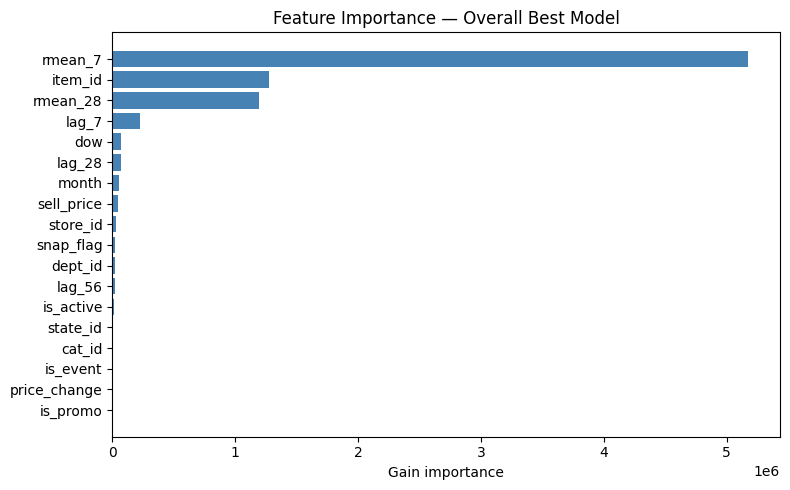

Saved feature_importance.png


In [ ]:
# Retrain best model (Optuna or grid, whichever won) to get feature importance
if optuna_best_rmse < grid_best_rmse:
    print('Using Optuna best params for feature importance plot.')
    fi_params = {
        'objective'              : 'tweedie',
        'metric'                 : 'rmse',
        'boosting_type'          : 'gbdt',
        'bagging_freq'           : 1,
        'verbosity'              : -1,
        'seed'                   : RANDOM_STATE,
        **optuna_best_params_raw,
    }
    fi_iter = optuna_best_iter
else:
    print('Using grid best params for feature importance plot.')
    fi_params = {**grid_best_params}
    fi_iter   = int(grid_df.iloc[0]['best_iteration'])

lgb_tr, lgb_va = make_datasets()
fi_model = lgb.train(
    params=fi_params,
    train_set=lgb_tr,
    num_boost_round=fi_iter,   # fixed rounds — no early stopping needed
    valid_sets=[lgb_va],
    valid_names=['valid'],
    callbacks=[lgb.log_evaluation(200)],
)

fi_df = pd.DataFrame({
    'feature'   : fi_model.feature_name(),
    'importance': fi_model.feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=False)

display(fi_df)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1], color='steelblue')
ax.set_xlabel('Gain importance')
ax.set_title('Feature Importance — Overall Best Model')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()
print('Saved feature_importance.png')

## 15. Save overall best params for Step 2

In [ ]:
if optuna_best_rmse < grid_best_rmse:
    # Optuna wins: reconstruct full param dict
    final_best_params = {
        'objective'              : 'tweedie',
        'metric'                 : 'rmse',
        'boosting_type'          : 'gbdt',
        'bagging_freq'           : 1,
        'verbosity'              : -1,
        'seed'                   : RANDOM_STATE,
        **optuna_best_params_raw,
    }
    source = f'optuna_trial_{study.best_trial.number}'
    best_rmse_final = optuna_best_rmse
    best_iter_final = optuna_best_iter
else:
    # Grid wins
    final_best_params = dict(grid_best_params)
    source            = grid_best_name
    best_rmse_final   = grid_best_rmse
    best_iter_final   = int(grid_df.iloc[0]['best_iteration'])

final_best_params['best_iteration_from_tuning']  = best_iter_final
final_best_params['validation_rmse_from_tuning'] = best_rmse_final
final_best_params['source']                      = source

with open('best_lgbm_params.json', 'w') as f:
    json.dump(final_best_params, f, indent=2)

print(f'Overall winner:  {source}')
print(f'Final best RMSE: {best_rmse_final:.6f}')
print(f'Best iteration:  {best_iter_final}')
print()
print('Saved best_lgbm_params.json:')
print(json.dumps(final_best_params, indent=2))

Overall winner:  optuna_trial_37
Final best RMSE: 2.002561
Best iteration:  152

Saved best_lgbm_params.json:
{
  "objective": "tweedie",
  "metric": "rmse",
  "boosting_type": "gbdt",
  "bagging_freq": 1,
  "verbosity": -1,
  "seed": 42,
  "learning_rate": 0.041858462747989315,
  "num_leaves": 91,
  "min_data_in_leaf": 85,
  "tweedie_variance_power": 1.2765900380701871,
  "lambda_l1": 0.8683198414627746,
  "lambda_l2": 0.35976328628132526,
  "feature_fraction": 0.6987745525049156,
  "bagging_fraction": 0.8688864780847736,
  "best_iteration_from_tuning": 152,
  "validation_rmse_from_tuning": 2.002561220831971,
  "source": "optuna_trial_37"
}


In [ ]:
import os
print(os.path.exists('best_lgbm_params.json'))  # should print True

True


In [ ]:
from google.colab import files
files.download('best_lgbm_params.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 16. Decision guide for Step 2

| Scenario | Action |
|---|---|
| Optuna improved over grid | Use `best_lgbm_params.json` — it holds the Optuna params |
| Grid held — Optuna didn't improve | Same file — it holds grid best params |
| RMSE still unsatisfying | Increase `N_OPTUNA_TRIALS` to 80+ and re-run Phase 2 only |
| Want to verify Tweedie assumption | Check feature importance — if `lag_7`/`lag_28` dominate, model is working correctly |

**For Step 2 (final training + recursive forecasting):**
1. Load `best_lgbm_params.json`
2. Retrain on **all 30,490 IDs** using `best_iteration_from_tuning` as `num_boost_round` (no early stopping on final run)
3. Run recursive forecasting loop for 28 days, updating lag features at each step